# **Step 1:** Importing Libraries and Connecting to Google Drive

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import os
from sklearn.model_selection import train_test_split
from google.colab import drive

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Step 2:** Reading Images and the Annotations File

In [ ]:
# Annotations for previous training:

data_path = '/content/drive/MyDrive/FinalProject/Images1'
# For running in Tamir's env: '/content/drive/MyDrive/Colab Notebooks/Intro ML & DL/suvelocity/Project Semi Supervised'
# For running in Nitzan's env:'/content/drive/MyDrive/FinalProject/Images1'
# Load the annotations file (x, y, angle)
annotations = np.load(os.path.join(data_path, 'agent_0_annotations.npy'))

# === ORIGINAL NORMALIZATION VALUES ===
max_x = 360.0 # Divided by the image width
max_y = 360.0 # Divided by the image height
max_angle = 360.0

# Normalize all annotations to [0, 1]
annotations = annotations / np.array([max_x, max_y, max_angle])

# Collect image file names
image_files = [f for f in os.listdir(data_path) if f.lower().endswith('.jpg')]

# Optional: Print image size to confirm (using first image)
img_sample = Image.open(os.path.join(data_path, image_files[0]))
print("Sample image size:", img_sample.size)  # (width, height)

Sample image size: (360, 360)


# **Step 3:** Custom Dataset Class

In [ ]:
# Define a custom dataset class by inheriting from PyTorch's Dataset base class
class CustomImageDataset(Dataset):
    def __init__(self, image_dir, image_files, annotations, transform=None): # Initialize the dataset with image directory, file list, annotations, and optional transforms
        self.image_dir = image_dir
        self.image_files = image_files
        self.annotations = annotations
        self.transform = transform

    def __len__(self): # Define how many items the dataset contains
        return len(self.image_files)

    def __getitem__(self, idx): # Get a single image and its corresponding annotation by index
        img_path = os.path.join(self.image_dir, self.image_files[idx])
        image = Image.open(img_path) #.convert("RGB") # Ensure image is in RGB format

        if self.transform:
            image = self.transform(image)

        # For Regression, the target is the numeric label (x, y, angle)
        label = torch.tensor(self.annotations[idx], dtype=torch.float32)
        return image, label

# **Step 4:** Image Transformation and Augmentation


In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# **Step 5:** Splitting into Train\Test and Preparing the DataLoader

In [ ]:
# User-provided list of images and angles
# We chose carefully 50 specific images to ensure a balanced distribution of angles across
# the entire 360-degree range.
# Each image in this list represents approximately a 7.2-degree interval
user_provided_data = [
    "agent_0454.jpg: 0.00 degrees", "agent_059.jpg: 7.54 degrees", "agent_061.jpg: 14.57 degrees",
    "agent_014.jpg: 22.29 degrees", "agent_0120.jpg: 29.41 degrees", "agent_0173.jpg: 37.35 degrees",
    "agent_0415.jpg: 43.32 degrees", "agent_0175.jpg: 50.44 degrees", "agent_0588.jpg: 57.95 degrees",
    "agent_0210.jpg: 65.22 degrees", "agent_0388.jpg: 72.35 degrees", "agent_0594.jpg: 80.64 degrees",
    "agent_0380.jpg: 86.50 degrees", "agent_0294.jpg: 95.44 degrees", "agent_0198.jpg: 101.61 degrees",
    "agent_0500.jpg: 108.16 degrees", "agent_0473.jpg: 115.56 degrees", "agent_0557.jpg: 124.45 degrees",
    "agent_0222.jpg: 130.24 degrees", "agent_0602.jpg: 137.00 degrees", "agent_0154.jpg: 145.01 degrees",
    "agent_036.jpg: 152.13 degrees", "agent_0224.jpg: 159.02 degrees", "agent_077.jpg: 169.32 degrees",
    "agent_0287.jpg: 173.57 degrees", "agent_0373.jpg: 180.63 degrees", "agent_0435.jpg: 188.24 degrees",
    "agent_0364.jpg: 195.07 degrees", "agent_0329.jpg: 202.43 degrees", "agent_0166.jpg: 208.81 degrees",
    "agent_074.jpg: 217.06 degrees", "agent_0434.jpg: 223.64 degrees", "agent_0396.jpg: 230.57 degrees",
    "agent_0317.jpg: 237.85 degrees", "agent_0567.jpg: 245.06 degrees", "agent_0433.jpg: 252.15 degrees",
    "agent_0483.jpg: 259.38 degrees", "agent_0163.jpg: 266.50 degrees", "agent_0183.jpg: 274.65 degrees",
    "agent_066.jpg: 281.16 degrees", "agent_010.jpg: 288.22 degrees", "agent_0336.jpg: 296.10 degrees",
    "agent_0411.jpg: 302.91 degrees", "agent_0426.jpg: 310.24 degrees", "agent_0538.jpg: 317.45 degrees",
    "agent_0332.jpg: 324.58 degrees", "agent_0476.jpg: 332.10 degrees", "agent_0449.jpg: 338.44 degrees",
    "agent_0177.jpg: 346.24 degrees", "agent_0107.jpg: 353.48 degrees"
]

selected_files_50 = []
selected_angles_50 = []

for entry in user_provided_data:
    parts = entry.split(': ')
    filename = parts[0]
    angle_str = parts[1].replace(' degrees', '')
    angle = np.float64(float(angle_str))

    selected_files_50.append(filename)
    selected_angles_50.append(angle)

print(f"Stored {len(selected_files_50)} filenames and angles.")
print("First 5 filenames:", selected_files_50[:5])
print("First 5 angles:", [f'{a:.2f}°' for a in selected_angles_50[:5]])

Stored 50 filenames and angles.
First 5 filenames: ['agent_0454.jpg', 'agent_059.jpg', 'agent_061.jpg', 'agent_014.jpg', 'agent_0120.jpg']
First 5 angles: ['0.00°', '7.54°', '14.57°', '22.29°', '29.41°']


In [ ]:
# Split the image filenames and annotations into training and testing sets (80% train, 20% test)
train_files_full_split, test_files, train_annots_full_split, test_annots = train_test_split(
    image_files, annotations, test_size=0.2, random_state=42
)
# random_state sets a fixed seed for random number generation, ensuring that the data split is the same every time you run the code
# Without random_state the split will change every time — making it impossible to reproduce or consistently compare results

# --- Reconstruct train_annots for the 50 selected balanced images with full (x, y, angle) ---
# 1. Create a mapping from filename to its index in the original image_files
file_to_idx = {filename: i for i, filename in enumerate(image_files)}

# 2. Initialize a list to hold the full (x, y, angle) annotations for the selected files
new_train_annots_list = []

# 3. Iterate through selected_files_50 and retrieve the full annotation vector from the global 'annotations' array
for filename in selected_files_50:
    original_idx = file_to_idx[filename]
    # 'annotations' is already normalized [x, y, angle]
    new_train_annots_list.append(annotations[original_idx])

# 4. Convert the list to a NumPy array
train_annots = np.array(new_train_annots_list)
train_files = selected_files_50

# Create datasets for regression
train_dataset = CustomImageDataset(data_path, train_files, train_annots, transform=transform)
test_dataset = CustomImageDataset(data_path, test_files, test_annots, transform=transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

In [ ]:
image, annotation = train_dataset.__getitem__(0)
print(image.shape)
print(annotation.shape)

torch.Size([3, 224, 224])
torch.Size([3])


# **Step 6:** Model Definition – Switching to ResNet18

In [ ]:
# Define a regression model based on pretrained ResNet18
class RegressionResNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Load a pretrained ResNet18 model
        self.model = models.resnet18(pretrained=False)

        # Replace the final fully-connected layer to output 3 values: x, y, angle
        self.model.fc = nn.Linear(self.model.fc.in_features, 3)

    def forward(self, x):
        x = self.model(x)              # Pass input through ResNet
        return torch.sigmoid(x)        # Ensure all outputs are in [0, 1]

# Create an instance of the model
net = RegressionResNet()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


# **Step 7:** Using GPU

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
net.to(device)

cuda


RegressionResNet(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tr

# **Step 8: Training with Standard MSE Loss**

# **Step 8.1:** Training preparations with Standard MSE Loss (Should run it only for MSE loss)

In [ ]:
# Define a new custom criterion for MSE that also returns individual components
def mse_component_loss(pred, target):
    # Split into (x, y) and angle components
    pred_xy = pred[:, :2]
    target_xy = target[:, :2]
    pred_angle = pred[:, 2]
    target_angle = target[:, 2]

    # Calculate MSE for (x, y) and angle separately
    xy_loss = F.mse_loss(pred_xy, target_xy)
    angle_loss = F.mse_loss(pred_angle, target_angle)

    # Combine them for the total loss used for backpropagation
    total_loss = xy_loss + angle_loss

    return total_loss, xy_loss, angle_loss

criterion = mse_component_loss # Use the new criterion
optimizer = optim.Adam(net.parameters(), lr=0.0001)

num_epochs = 300
loss_list = [] # Stores total loss
xy_loss_list = [] # New list to store XY losses
angle_loss_list = [] # New list to store angle losses

# **Step 8.2:** Training with Standard MSE Loss

In [ ]:
# Training loop:

test_xy_rmse_list = [] # Initialize new list to store test XY RMSE
test_angle_rmse_list = [] # Initialize new list to store test Angle RMSE

for epoch in range(num_epochs):
    net.train()
    running_total_loss = 0.0
    running_xy_loss = 0.0
    running_angle_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        # The criterion now returns total_loss for backward, and individual losses for logging
        total_loss, xy_loss, angle_loss = criterion(net(inputs), labels)
        total_loss.backward()
        optimizer.step()

        running_total_loss += total_loss.item() * inputs.size(0)
        running_xy_loss += xy_loss.item() * inputs.size(0)
        running_angle_loss += angle_loss.item() * inputs.size(0)

    epoch_total_loss = running_total_loss / len(train_loader.dataset)
    epoch_xy_loss = running_xy_loss / len(train_loader.dataset) # Calculate average XY loss for the epoch in MSE (normalized)
    epoch_angle_loss = running_angle_loss / len(train_loader.dataset) # Calculate average Angle loss for the epoch in MSE (rad^2)

    epoch_xy_pixels = np.sqrt(epoch_xy_loss) * 224 # Convert MSE (normalized) to RMSE (pixels) - image size = 224
    epoch_angle_degrees = np.sqrt(epoch_angle_loss) * (180 / np.pi) # Convert MSE (rad^2) to RMSE (degrees)

    loss_list.append(epoch_total_loss)
    xy_loss_list.append(epoch_xy_pixels)
    angle_loss_list.append(epoch_angle_degrees)

    print(f"Epoch [{epoch+1}/{num_epochs}], Total Loss: {epoch_total_loss:.4f}, XY Loss: {epoch_xy_pixels:.4f}, Angle Loss: {epoch_angle_degrees:.4f}")

    # --- Evaluation on test set ---
    net.eval()
    test_total_mse_xy = 0.0
    test_total_mse_angle = 0.0
    test_total_samples = 0
    img_size = 224 # Assuming image size is 224x224 as set in transform

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)

            pred_xy = outputs[:, :2]
            true_xy = labels[:, :2]
            pred_angle = outputs[:, 2]
            true_angle = labels[:, 2]

            # Calculate MSE for (x, y)
            mse_xy = F.mse_loss(pred_xy, true_xy, reduction='sum')
            test_total_mse_xy += mse_xy.item()

            # Calculate regular MSE for angle
            mse_angle = F.mse_loss(pred_angle, true_angle, reduction='sum')
            test_total_mse_angle += mse_angle.item()

            test_total_samples += inputs.size(0)

    # Calculate average test RMSE
    avg_test_mse_xy = test_total_mse_xy / test_total_samples
    avg_test_mse_angle = test_total_mse_angle / test_total_samples

    test_rmse_xy_pixels = (avg_test_mse_xy ** 0.5) * img_size
    test_rmse_angle_degrees = (avg_test_mse_angle ** 0.5) * (180.0 / np.pi)

    test_xy_rmse_list.append(test_rmse_xy_pixels)
    test_angle_rmse_list.append(test_rmse_angle_degrees)

    print(f"Test Set RMSE after Epoch {epoch+1}: XY: {test_rmse_xy_pixels:.2f} pixels, Angle: {test_rmse_angle_degrees:.2f} degrees\n")

    net.train()

print("Regression Model training finished")

Epoch [1/300], Total Loss: 0.1060, XY Loss: 25.5587, Angle Loss: 17.4757
Test Set RMSE after Epoch 1: XY: 32.94 pixels, Angle: 16.31 degrees

Epoch [2/300], Total Loss: 0.0458, XY Loss: 13.0803, Angle Loss: 11.8008
Test Set RMSE after Epoch 2: XY: 32.86 pixels, Angle: 17.57 degrees

Epoch [3/300], Total Loss: 0.0253, XY Loss: 10.7296, Angle Loss: 8.6917
Test Set RMSE after Epoch 3: XY: 48.10 pixels, Angle: 18.30 degrees

Epoch [4/300], Total Loss: 0.0142, XY Loss: 9.0257, Angle Loss: 6.4244
Test Set RMSE after Epoch 4: XY: 60.57 pixels, Angle: 17.77 degrees

Epoch [5/300], Total Loss: 0.0073, XY Loss: 6.7599, Angle Loss: 4.5748
Test Set RMSE after Epoch 5: XY: 69.00 pixels, Angle: 17.88 degrees

Epoch [6/300], Total Loss: 0.0063, XY Loss: 6.3199, Angle Loss: 4.2317
Test Set RMSE after Epoch 6: XY: 72.62 pixels, Angle: 18.37 degrees

Epoch [7/300], Total Loss: 0.0109, XY Loss: 5.5300, Angle Loss: 5.8197
Test Set RMSE after Epoch 7: XY: 72.28 pixels, Angle: 17.70 degrees

Epoch [8/300], 

# **Step 8.3:** Graph

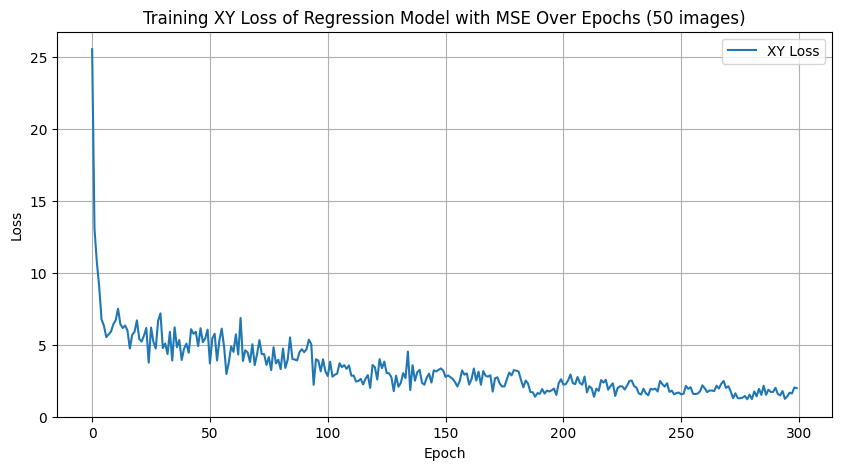

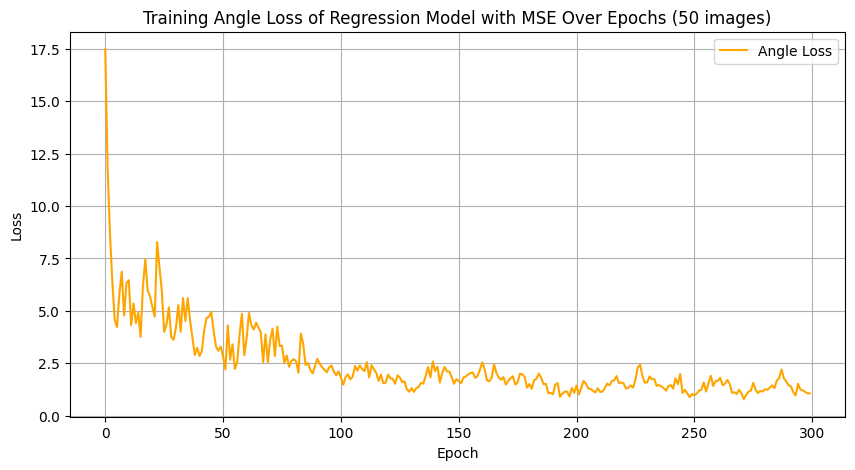

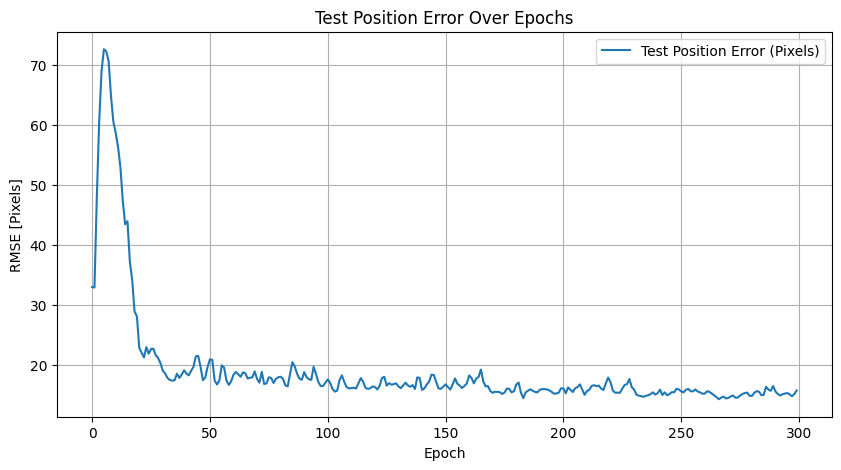

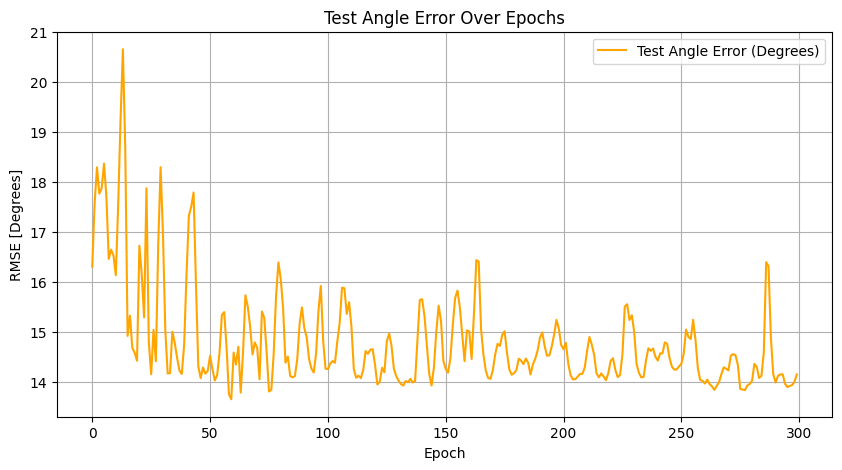

In [ ]:
# --- Plot for XY Position Error in Train ---
plt.figure(figsize=(10, 5))
plt.plot(xy_loss_list, label='XY Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training XY Loss of Regression Model with MSE Over Epochs (50 images)')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot for Angle Error in Train ---
plt.figure(figsize=(10, 5))
plt.plot(angle_loss_list, label='Angle Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Angle Loss of Regression Model with MSE Over Epochs (50 images)')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot for XY Position Error in Test ---
plt.figure(figsize=(10, 5))
plt.plot(test_xy_rmse_list, label='Test Position Error (Pixels)')
plt.xlabel('Epoch')
plt.ylabel('RMSE [Pixels]')
plt.title('Test Position Error Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot for Angle Error in Test ---
plt.figure(figsize=(10, 5))
plt.plot(test_angle_rmse_list, label='Test Angle Error (Degrees)', color='orange')
plt.xlabel('Epoch')
plt.ylabel('RMSE [Degrees]')
plt.title('Test Angle Error Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# **Step 8.4:** Test the network on the data

Ground truth (x, y, angle):
[[0.5        0.45555556 0.70497495]
 [0.5        0.12777779 0.7984644 ]
 [0.5        0.5        0.6875571 ]
 [0.5        0.3638889  0.4826277 ]
 [0.5        0.2888889  0.7828947 ]
 [0.3611111  0.5        0.6718785 ]
 [0.5        0.5        0.824832  ]
 [0.5        0.14722222 0.6526127 ]
 [0.5        0.36944443 0.29012233]
 [0.3        0.45277777 0.27380317]
 [0.5        0.5        0.3620365 ]
 [0.5        0.49722221 0.06881984]
 [0.5        0.44722223 0.812341  ]
 [0.5        0.48333332 0.22709355]
 [0.5        0.5        0.9297841 ]
 [0.5        0.5        0.69316036]]
Predicted (x, y, angle):
[[0.5037608  0.4340285  0.48997584]
 [0.51318014 0.26305944 0.64469624]
 [0.5088302  0.50281096 0.64726096]
 [0.5134203  0.36337078 0.42990556]
 [0.5171619  0.28873372 0.6536333 ]
 [0.46787012 0.48479345 0.32296503]
 [0.51147044 0.45140135 0.65233135]
 [0.5031926  0.30137035 0.60871464]
 [0.491144   0.366401   0.3651521 ]
 [0.40900424 0.43319687 0.3847131 ]
 [0.514775

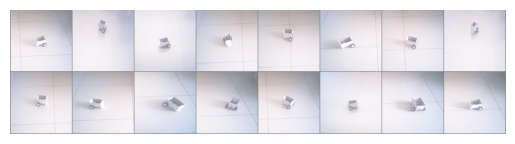

In [ ]:
def imshow(img): # Define a function to display a batch of images
    img = img * 0.5 + 0.5  # Reverse the normalization to convert the image back to [0, 1] range for visualization
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(test_loader) # Provides one item at a time when using next()
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Run predictions
net.eval()
with torch.no_grad():
    outputs = net(images)

print("Ground truth (x, y, angle):")
print(labels.cpu().numpy())
print("Predicted (x, y, angle):")
print(outputs.cpu().numpy())

imshow(torchvision.utils.make_grid(images.cpu()))


# **Step 8.5:** Calculate the square Loss

In [ ]:
def evaluate_model(model, test_loader, device, img_size=224):
  total_samples = 0
  total_mse_xy = 0.0
  total_mse_angle = 0.0

  with torch.no_grad():
      for inputs, labels in test_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          outputs = net(inputs)

          pred_xy = outputs[:, :2]
          true_xy = labels[:, :2]
          pred_angle = outputs[:, 2]
          true_angle = labels[:, 2]

          # Calculate MSE for (x, y) as a single value
          mse_xy = F.mse_loss(pred_xy, true_xy, reduction='sum')  # sum over all samples
          total_mse_xy += mse_xy.item()

          # Calculate angle difference using atan2
          angle_diff = torch.atan2(
              torch.sin(2 * np.pi * (pred_angle - true_angle)),
              torch.cos(2 * np.pi * (pred_angle - true_angle))
          )
          mse_angle = torch.sum(angle_diff ** 2)  # sum over all samples
          total_mse_angle += mse_angle.item()

          total_samples += inputs.size(0)

  # Average losses
  avg_mse_xy = total_mse_xy / total_samples # Normalized units
  avg_mse_angle = total_mse_angle / total_samples # radians^2

  # Root mean square errors
  rmse_xy_norm = avg_mse_xy ** 0.5 # Normalized
  rmse_xy_pixels = rmse_xy_norm * img_size

  rmse_angle_rad = (avg_mse_angle ** 0.5)
  rmse_angle_deg = rmse_angle_rad * (180.0 / np.pi)

  epoch_xy_pixels = np.sqrt(epoch_xy_loss) * 224
  epoch_angle_degrees = np.sqrt(epoch_angle_loss) * (180 / np.pi)

  print("For Regression model with MSE:")
  print(f"Average MSE for Position (X & Y) on test data: {avg_mse_xy:.4f}")
  print(f"RMSE Position on test data: {rmse_xy_pixels:.2f} pixels")

  print(f"Average MSE for Angle on test data: {avg_mse_angle:.4f} rad^2")
  print(f"RMSE Angle on test data: {rmse_angle_deg:.2f} degrees")
  print(f"RMSE Angle on train data: {epoch_angle_degrees:.2f} degrees")
  print(f"RMSE Position on train data: {epoch_xy_pixels:.2f} pixels")

In [ ]:
evaluate_model(net, test_loader, device)

For Regression model with MSE:
Average MSE for Position (X & Y) on test data: 0.0049
RMSE Position on test data: 15.68 pixels
Average MSE for Angle on test data: 2.2013 rad^2
RMSE Angle on test data: 85.01 degrees
RMSE Angle on train data: 1.06 degrees
RMSE Position on train data: 1.98 pixels


# **Step 8.6:** Display 5 Test Images with Original + Predicted Arrows

In [ ]:
def plot_image_with_arrows(image, predicted_pose, true_pose):
    # Convert image tensor to NumPy and clip values for display
    img_np = image.cpu().numpy().transpose((1, 2, 0))
    img_np = np.clip(img_np, 0, 1)
    h, w = img_np.shape[:2]

    # === Denormalize predicted pose ===
    pred_x = predicted_pose[0] * w      # from [0,1] * image width
    pred_y = predicted_pose[1] * h      # from [0,1] * image height
    pred_angle_deg = predicted_pose[2] * 360
    pred_angle_deg = -pred_angle_deg+90
    pred_angle_rad = np.deg2rad(pred_angle_deg)

    # === Denormalize true pose ===
    true_x = true_pose[0] * w
    true_y = true_pose[1] * h
    true_angle_deg = true_pose[2] * 360
    true_angle_deg = -true_angle_deg+90
    true_angle_rad = np.deg2rad(true_angle_deg)

    arrow_len = 40

    # Plot image
    plt.imshow(img_np)

    # Predicted arrow (RED)
    plt.arrow(pred_x, pred_y,
              arrow_len * np.cos(pred_angle_rad),
              -arrow_len * np.sin(pred_angle_rad),
              head_width=6, head_length=8, fc='red', ec='red')

    # Ground truth arrow (BLUE)
    plt.arrow(true_x, true_y,
              arrow_len * np.cos(true_angle_rad),
              -arrow_len * np.sin(true_angle_rad),
              head_width=6, head_length=8, fc='blue', ec='blue')

    print(f"Predicted X norm: {predicted_pose[0]}, denorm: {pred_x}")
    print(f"True X norm: {true_pose[0]}, denorm: {true_x}")


    # Display title and remove axes
    plt.title(f"Pred: ({pred_x:.1f}, {pred_y:.1f}, {pred_angle_deg:.1f}°) | "
              f"True: ({true_x:.1f}, {true_y:.1f}, {true_angle_deg:.1f}°)")
    plt.axis('off')
    plt.show()


# Function to visualize predictions of 5 images
def visualize_predictions(net, test_loader, device, num_images=5):
    net.eval()
    shown = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)

            for i in range(images.size(0)):
                if shown >= num_images:
                    return

                predicted = outputs[i].cpu().numpy()
                true = labels[i].cpu().numpy()

                print(f"\nImage {shown + 1}:")
                print("  Ground Truth (x, y, angle):", true * np.array([224, 224, 360]))
                print("  Predicted     (x, y, angle):", predicted * np.array([224, 224, 360]))

                plot_image_with_arrows(images[i], predicted, true)
                shown += 1


Image 1:
  Ground Truth (x, y, angle): [112.         102.04444504 253.79098177]
  Predicted     (x, y, angle): [112.84242249  97.22238541 176.39130235]
Predicted X norm: 0.503760814666748, denorm: 112.84242248535156
True X norm: 0.5, denorm: 112.0


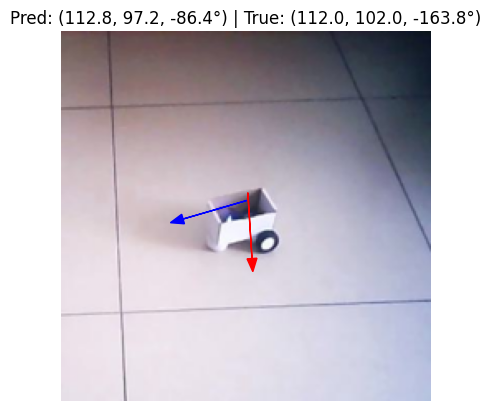


Image 2:
  Ground Truth (x, y, angle): [112.          28.62222385 287.44719028]
  Predicted     (x, y, angle): [114.95235062  58.92531395 232.09064484]
Predicted X norm: 0.513180136680603, denorm: 114.95234680175781
True X norm: 0.5, denorm: 112.0


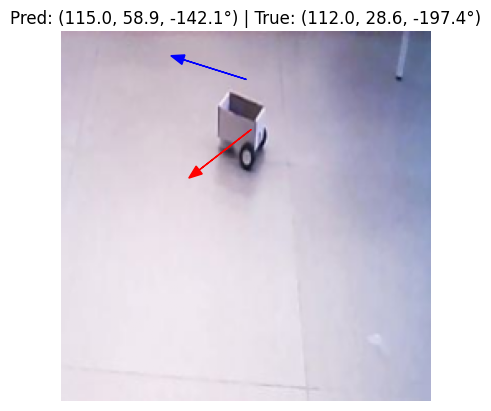


Image 3:
  Ground Truth (x, y, angle): [112.         112.         247.52055645]
  Predicted     (x, y, angle): [113.97796249 112.62965393 233.01394701]
Predicted X norm: 0.508830189704895, denorm: 113.97796630859375
True X norm: 0.5, denorm: 112.0


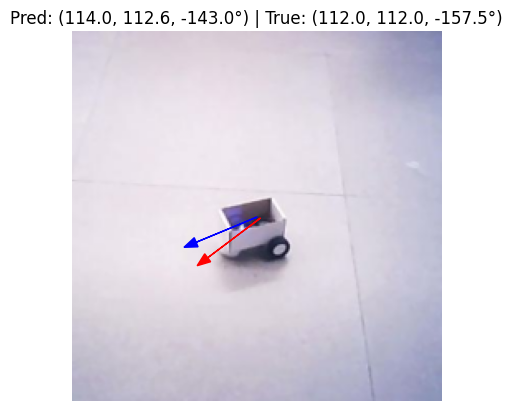


Image 4:
  Ground Truth (x, y, angle): [112.          81.51111126 173.74596834]
  Predicted     (x, y, angle): [115.00614357  81.39505386 154.76600289]
Predicted X norm: 0.5134202837944031, denorm: 115.00614166259766
True X norm: 0.5, denorm: 112.0


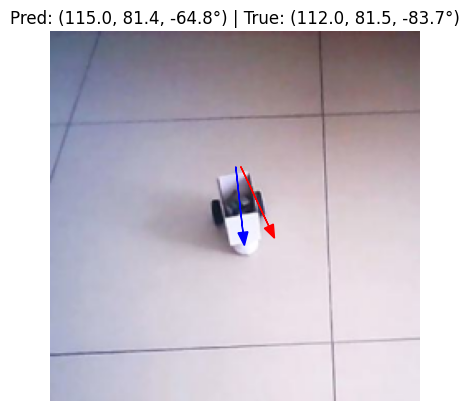


Image 5:
  Ground Truth (x, y, angle): [112.          64.71111393 281.84208155]
  Predicted     (x, y, angle): [115.84426689  64.67635345 235.30798674]
Predicted X norm: 0.5171619057655334, denorm: 115.84426879882812
True X norm: 0.5, denorm: 112.0


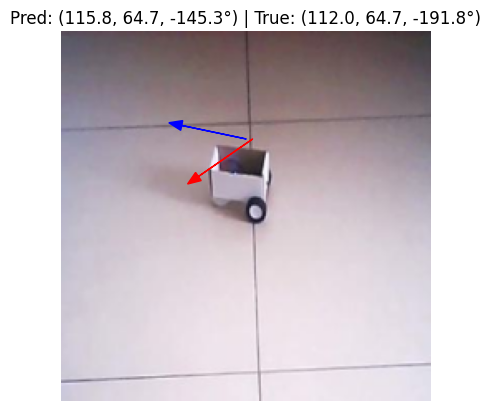

In [ ]:
visualize_predictions(net, test_loader, device)

# **Step 8.7:** Show Accuracy for X, Y and Angle Predictions on Test Set separately

In [ ]:
def evaluate_pose_accuracy(net, test_loader, device):
    net.eval()

    total_samples = 0
    total_x_error = 0.0
    total_y_error = 0.0
    total_angle_error = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)

            # Unnormalize both predictions and labels
            preds = outputs.cpu().numpy() * np.array([max_x, max_y, max_angle])
            trues = labels.cpu().numpy() * np.array([max_x, max_y, max_angle])

            # Compute absolute errors
            total_x_error += np.abs(preds[:, 0] - trues[:, 0]).sum()
            total_y_error += np.abs(preds[:, 1] - trues[:, 1]).sum()
            total_angle_error += np.abs(preds[:, 2] - trues[:, 2]).sum()
            total_samples += preds.shape[0]

    # Compute mean errors (MAE)
    mean_x_error = total_x_error / total_samples
    mean_y_error = total_y_error / total_samples
    mean_angle_error = total_angle_error / total_samples

    print("Prediction Accuracy on Test Set:")
    print(f"  Mean Absolute Error in X:     {mean_x_error:.2f} pixels")
    print(f"  Mean Absolute Error in Y:     {mean_y_error:.2f} pixels")
    print(f"  Mean Absolute Error in Angle: {mean_angle_error:.2f} degrees")


In [ ]:
evaluate_pose_accuracy(net, test_loader, device)

Prediction Accuracy on Test Set:
  Mean Absolute Error in X:     10.53 pixels
  Mean Absolute Error in Y:     10.32 pixels
  Mean Absolute Error in Angle: 68.44 degrees


# **Step 9: Training with new Loss Function (should run only for new Loss Function)**

# **Step 9.1:** Training preparations with new Loss Function

In [ ]:
net = RegressionResNet()
net.to(device)

# Custom loss function: combines MSE for (x, y) and atan2-based loss for angle
def custom_pose_loss(pred, target):
    # Split into (x, y) and angle
    pred_xy = pred[:, :2]
    target_xy = target[:, :2]
    pred_angle = pred[:, 2]
    target_angle = target[:, 2]

    # MSE for (x, y)
    xy_loss = F.mse_loss(pred_xy, target_xy)

    # Use 2π to account for full circle (normalized angles from 0 to 1)
    angle_diff = torch.atan2(
        torch.sin(2 * np.pi * (pred_angle - target_angle)),
        torch.cos(2 * np.pi * (pred_angle - target_angle))
    )
    angle_loss = torch.mean(angle_diff ** 2)

    # Combine the two losses
    total_loss = xy_loss + angle_loss
    return total_loss, xy_loss, angle_loss

criterion = custom_pose_loss
optimizer = optim.Adam(net.parameters(), lr=0.0001)

num_epochs = 300
loss_list = [] # Stores total loss
xy_loss_list = [] # New list to store XY losses
angle_loss_list = [] # New list to store angle losses

# **Step 9.2:** Training with new Loss Function

In [ ]:
num_epochs=300

test_xy_rmse_list = [] # Initialize new list to store test XY RMSE
test_angle_rmse_list = [] # Initialize new list to store test Angle RMSE

for epoch in range(num_epochs):
    net.train()
    running_loss = 0.0
    running_xy_loss = 0.0 # New running total for XY loss
    running_angle_loss = 0.0 # New running total for Angle loss

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = net(inputs)
        total_loss, xy_l, angle_l = custom_pose_loss(outputs, labels) # Get individual losses
        total_loss.backward()
        optimizer.step() # Update the model's weights using the calculated gradients

        running_loss += total_loss.item() * inputs.size(0) # Accumulate total loss
        running_xy_loss += xy_l.item() * inputs.size(0) # Accumulate XY loss item
        running_angle_loss += angle_l.item() * inputs.size(0) # Accumulate Angle loss item

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_xy_loss = running_xy_loss / len(train_loader.dataset) # Calculate average XY loss for the epoch in MSE (normalized)
    epoch_angle_loss = running_angle_loss / len(train_loader.dataset) # Calculate average Angle loss for the epoch in MSE (rad^2)

    epoch_xy_pixels = np.sqrt(epoch_xy_loss) * 224 # Convert MSE (normalized) to RMSE (pixels) - image size = 224
    epoch_angle_degrees = np.sqrt(epoch_angle_loss) * (180 / np.pi) # Convert MSE (rad^2) to RMSE (degrees)

    loss_list.append(epoch_loss)
    xy_loss_list.append(epoch_xy_pixels) # Store average XY loss
    angle_loss_list.append(epoch_angle_degrees) # Store average Angle loss

    print(f"Epoch [{epoch+1}/{num_epochs}], Total Loss: {epoch_loss:.4f}, XY Loss: {epoch_xy_pixels:.4f}, Angle Loss: {epoch_angle_degrees:.4f}") # Updated print

    # --- Evaluation on test set ---
    net.eval()
    test_total_mse_xy = 0.0
    test_total_mse_angle = 0.0
    test_total_samples = 0
    img_size = 224 # Assuming image size is 224x224 as set in transform

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = net(inputs)

            pred_xy = outputs[:, :2]
            true_xy = labels[:, :2]
            pred_angle = outputs[:, 2]
            true_angle = labels[:, 2]

            # Calculate MSE for (x, y)
            mse_xy = F.mse_loss(pred_xy, true_xy, reduction='sum')
            test_total_mse_xy += mse_xy.item()

            # Calculate angle difference using atan2 for cyclic loss
            angle_diff = torch.atan2(
                torch.sin(2 * np.pi * (pred_angle - true_angle)),
                torch.cos(2 * np.pi * (pred_angle - true_angle))
            )
            mse_angle = torch.sum(angle_diff ** 2)
            test_total_mse_angle += mse_angle.item()

            test_total_samples += inputs.size(0)

    # Calculate average test RMSE
    avg_test_mse_xy = test_total_mse_xy / test_total_samples
    avg_test_mse_angle = test_total_mse_angle / test_total_samples

    test_rmse_xy_pixels = (avg_test_mse_xy ** 0.5) * img_size
    test_rmse_angle_degrees = (avg_test_mse_angle ** 0.5) * (180.0 / np.pi)

    test_xy_rmse_list.append(test_rmse_xy_pixels)
    test_angle_rmse_list.append(test_rmse_angle_degrees)

    # print(f"Test Set RMSE after Epoch {epoch+1}: XY: {test_rmse_xy_pixels:.2f} pixels, Angle: {test_rmse_angle_degrees:.2f} degrees\n")

    net.train()

print("Regression mode training finished")

Epoch [1/300], Total Loss: 2.9575, XY Loss: 32.7843, Angle Loss: 98.1758
Epoch [2/300], Total Loss: 1.5051, XY Loss: 26.3426, Angle Loss: 69.9676
Epoch [3/300], Total Loss: 1.0593, XY Loss: 22.5481, Angle Loss: 58.6882
Epoch [4/300], Total Loss: 0.9095, XY Loss: 20.2094, Angle Loss: 54.3963
Epoch [5/300], Total Loss: 0.6559, XY Loss: 19.0990, Angle Loss: 46.1445
Epoch [6/300], Total Loss: 0.2826, XY Loss: 18.8277, Angle Loss: 30.0728
Epoch [7/300], Total Loss: 0.3210, XY Loss: 18.8772, Angle Loss: 32.0999
Epoch [8/300], Total Loss: 0.6923, XY Loss: 18.4595, Angle Loss: 47.4396
Epoch [9/300], Total Loss: 0.3701, XY Loss: 17.8110, Angle Loss: 34.5584
Epoch [10/300], Total Loss: 0.3814, XY Loss: 18.2922, Angle Loss: 35.0735
Epoch [11/300], Total Loss: 0.4110, XY Loss: 17.8405, Angle Loss: 36.4474
Epoch [12/300], Total Loss: 0.4210, XY Loss: 17.2100, Angle Loss: 36.9126
Epoch [13/300], Total Loss: 0.4577, XY Loss: 18.2857, Angle Loss: 38.4795
Epoch [14/300], Total Loss: 0.5110, XY Loss: 17

# **Step 9.3:** Graph

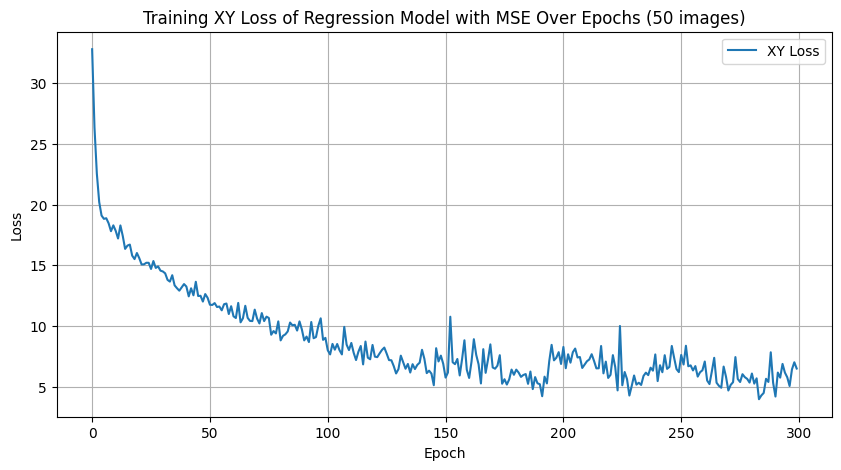

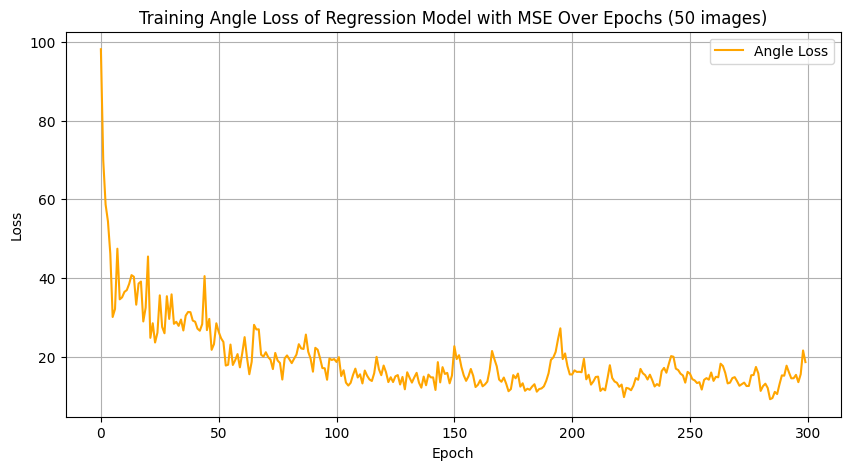

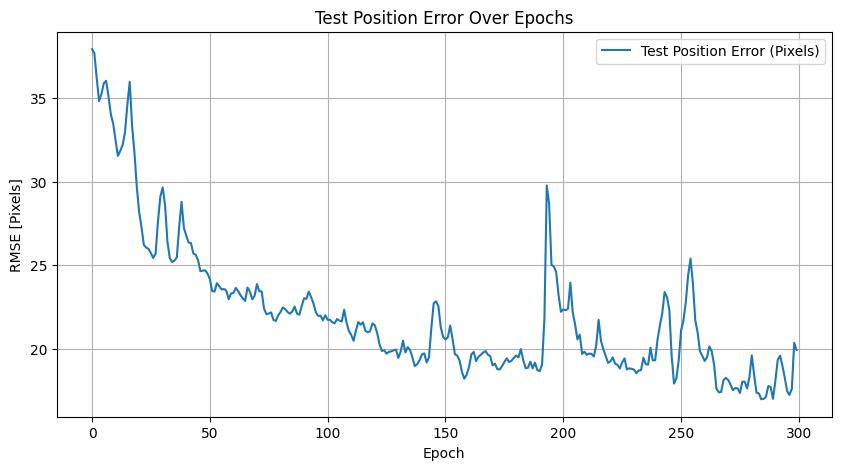

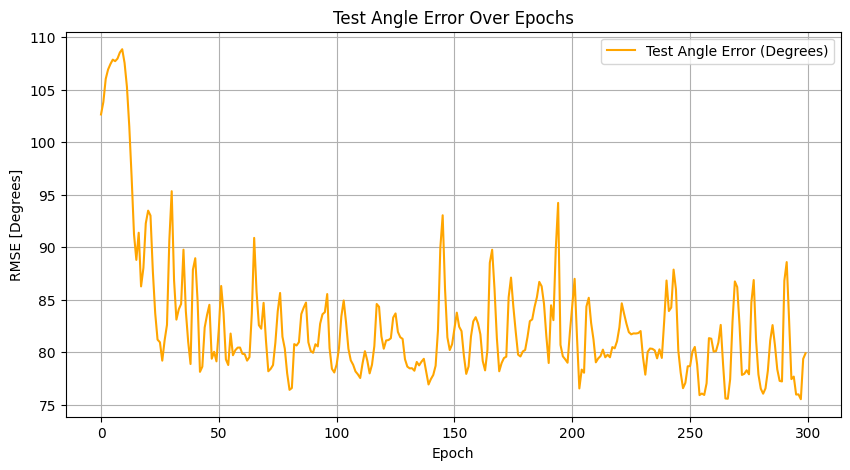

In [ ]:
# --- Plot for XY Position Error in Train ---
plt.figure(figsize=(10, 5))
plt.plot(xy_loss_list, label='XY Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training XY Loss of Regression Model with MSE Over Epochs (50 images)')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot for Angle Error in Train ---
plt.figure(figsize=(10, 5))
plt.plot(angle_loss_list, label='Angle Loss', color='orange')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Angle Loss of Regression Model with MSE Over Epochs (50 images)')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot for XY Position Error in Test ---
plt.figure(figsize=(10, 5))
plt.plot(test_xy_rmse_list, label='Test Position Error (Pixels)')
plt.xlabel('Epoch')
plt.ylabel('RMSE [Pixels]')
plt.title('Test Position Error Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# --- Plot for Angle Error in Test ---
plt.figure(figsize=(10, 5))
plt.plot(test_angle_rmse_list, label='Test Angle Error (Degrees)', color='orange')
plt.xlabel('Epoch')
plt.ylabel('RMSE [Degrees]')
plt.title('Test Angle Error Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# **Step 9.4:** Test the network on the data

Ground truth (x, y, angle):
[[0.5        0.45555556 0.70497495]
 [0.5        0.12777779 0.7984644 ]
 [0.5        0.5        0.6875571 ]
 [0.5        0.3638889  0.4826277 ]
 [0.5        0.2888889  0.7828947 ]
 [0.3611111  0.5        0.6718785 ]
 [0.5        0.5        0.824832  ]
 [0.5        0.14722222 0.6526127 ]
 [0.5        0.36944443 0.29012233]
 [0.3        0.45277777 0.27380317]
 [0.5        0.5        0.3620365 ]
 [0.5        0.49722221 0.06881984]
 [0.5        0.44722223 0.812341  ]
 [0.5        0.48333332 0.22709355]
 [0.5        0.5        0.9297841 ]
 [0.5        0.5        0.69316036]]
Predicted (x, y, angle):
[[0.5144439  0.3797626  0.7091396 ]
 [0.5008304  0.34327626 0.4907611 ]
 [0.49304417 0.44243592 0.5186088 ]
 [0.46795937 0.32015234 0.49296305]
 [0.50177187 0.2992108  0.5957975 ]
 [0.45616257 0.4184882  0.39471278]
 [0.49730015 0.39687362 0.57167166]
 [0.48298505 0.35244188 0.42418548]
 [0.4705686  0.3648954  0.48176578]
 [0.44195205 0.38453028 0.4298366 ]
 [0.522580

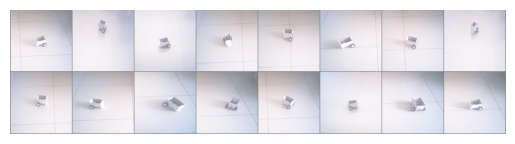

In [ ]:
def imshow(img): # Define a function to display a batch of images
    img = img * 0.5 + 0.5  # Reverse the normalization to convert the image back to [0, 1] range for visualization
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

dataiter = iter(test_loader) # Provides one item at a time when using next()
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

# Run predictions
net.eval()
with torch.no_grad():
    outputs = net(images)

print("Ground truth (x, y, angle):")
print(labels.cpu().numpy())
print("Predicted (x, y, angle):")
print(outputs.cpu().numpy())

imshow(torchvision.utils.make_grid(images.cpu()))


# **Step 9.5:** Calculate the square Loss

In [ ]:
def evaluate_model(model, test_loader, device, img_size=224):
  total_samples = 0
  total_mse_xy = 0.0
  total_mse_angle = 0.0

  with torch.no_grad():
      for inputs, labels in test_loader:
          inputs, labels = inputs.to(device), labels.to(device)
          outputs = net(inputs)

          pred_xy = outputs[:, :2]
          true_xy = labels[:, :2]
          pred_angle = outputs[:, 2]
          true_angle = labels[:, 2]

          # Calculate MSE for (x, y) as a single value
          mse_xy = F.mse_loss(pred_xy, true_xy, reduction='sum')  # sum over all samples
          total_mse_xy += mse_xy.item()

          # Calculate angle difference using atan2
          angle_diff = torch.atan2(
              torch.sin(2 * np.pi * (pred_angle - true_angle)),
              torch.cos(2 * np.pi * (pred_angle - true_angle))
          )
          mse_angle = torch.sum(angle_diff ** 2)  # sum over all samples
          total_mse_angle += mse_angle.item()

          total_samples += inputs.size(0)

  # Average losses
  avg_mse_xy = total_mse_xy / total_samples # Normalized units
  avg_mse_angle = total_mse_angle / total_samples # radians^2

  # Root mean square errors
  rmse_xy_norm = avg_mse_xy ** 0.5 # Normalized
  rmse_xy_pixels = rmse_xy_norm * img_size

  rmse_angle_rad = (avg_mse_angle ** 0.5)
  rmse_angle_deg = rmse_angle_rad * (180.0 / np.pi)

  print("For Regression model with MSE:")
  print(f"Average MSE for Position (X & Y) on test data: {avg_mse_xy:.4f}")
  print(f"RMSE Position on test data: {rmse_xy_pixels:.2f} pixels")

  print(f"Average MSE for Angle on test data: {avg_mse_angle:.4f} rad^2")
  print(f"RMSE Angle on test data: {rmse_angle_deg:.2f} degrees")
  print(f"RMSE Angle on train data: {epoch_angle_degrees:.2f} degrees")
  print(f"RMSE Position on train data: {epoch_xy_pixels:.2f} pixels")

In [ ]:
evaluate_model(net, test_loader, device)

For Regression model with MSE:
Average MSE for Position (X & Y) on test data: 0.0079
RMSE Position on test data: 19.94 pixels
Average MSE for Angle on test data: 1.9451 rad^2
RMSE Angle on test data: 79.91 degrees
RMSE Angle on train data: 18.59 degrees
RMSE Position on train data: 6.51 pixels


# **Step 9.6:** Display 5 Test Images with Original + Predicted Arrows

In [ ]:
def plot_image_with_arrows(image, predicted_pose, true_pose):
    # Convert image tensor to NumPy and clip values for display
    img_np = image.cpu().numpy().transpose((1, 2, 0))
    img_np = np.clip(img_np, 0, 1)
    h, w = img_np.shape[:2]

    # === Denormalize predicted pose ===
    pred_x = predicted_pose[0] * w      # from [0,1] * image width
    pred_y = predicted_pose[1] * h      # from [0,1] * image height
    pred_angle_deg = predicted_pose[2] * 360
    pred_angle_deg = -pred_angle_deg+90
    pred_angle_rad = np.deg2rad(pred_angle_deg)

    # === Denormalize true pose ===
    true_x = true_pose[0] * w
    true_y = true_pose[1] * h
    true_angle_deg = true_pose[2] * 360
    true_angle_deg = -true_angle_deg+90
    true_angle_rad = np.deg2rad(true_angle_deg)

    arrow_len = 40

    # Plot image
    plt.imshow(img_np)

    # Predicted arrow (RED)
    plt.arrow(pred_x, pred_y,
              arrow_len * np.cos(pred_angle_rad),
              -arrow_len * np.sin(pred_angle_rad),
              head_width=6, head_length=8, fc='red', ec='red')

    # Ground truth arrow (BLUE)
    plt.arrow(true_x, true_y,
              arrow_len * np.cos(true_angle_rad),
              -arrow_len * np.sin(true_angle_rad),
              head_width=6, head_length=8, fc='blue', ec='blue')

    print(f"Predicted X norm: {predicted_pose[0]}, denorm: {pred_x}")
    print(f"True X norm: {true_pose[0]}, denorm: {true_x}")


    # Display title and remove axes
    plt.title(f"Pred: ({pred_x:.1f}, {pred_y:.1f}, {pred_angle_deg:.1f}°) | "
              f"True: ({true_x:.1f}, {true_y:.1f}, {true_angle_deg:.1f}°)")
    plt.axis('off')
    plt.show()


# Function to visualize predictions of 5 images
def visualize_predictions(net, test_loader, device, num_images=5):
    net.eval()
    shown = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)

            for i in range(images.size(0)):
                if shown >= num_images:
                    return

                predicted = outputs[i].cpu().numpy()
                true = labels[i].cpu().numpy()

                print(f"\nImage {shown + 1}:")
                print("  Ground Truth (x, y, angle):", true * np.array([224, 224, 360]))
                print("  Predicted     (x, y, angle):", predicted * np.array([224, 224, 360]))

                plot_image_with_arrows(images[i], predicted, true)
                shown += 1


Image 1:
  Ground Truth (x, y, angle): [112.         102.04444504 253.79098177]
  Predicted     (x, y, angle): [115.23542786  85.06682014 255.29025078]
Predicted X norm: 0.5144438743591309, denorm: 115.23542785644531
True X norm: 0.5, denorm: 112.0


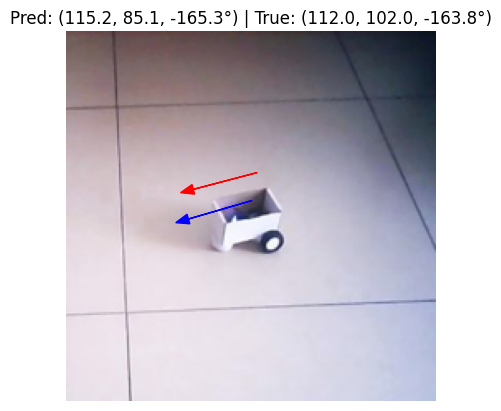


Image 2:
  Ground Truth (x, y, angle): [112.          28.62222385 287.44719028]
  Predicted     (x, y, angle): [112.18601227  76.89388275 176.67399645]
Predicted X norm: 0.5008304119110107, denorm: 112.1860122680664
True X norm: 0.5, denorm: 112.0


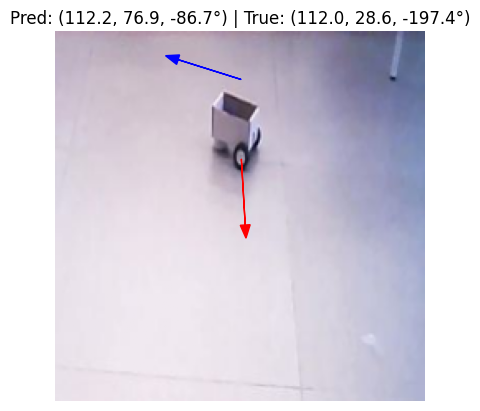


Image 3:
  Ground Truth (x, y, angle): [112.         112.         247.52055645]
  Predicted     (x, y, angle): [110.44189358  99.10564613 186.69917107]
Predicted X norm: 0.4930441677570343, denorm: 110.44189453125
True X norm: 0.5, denorm: 112.0


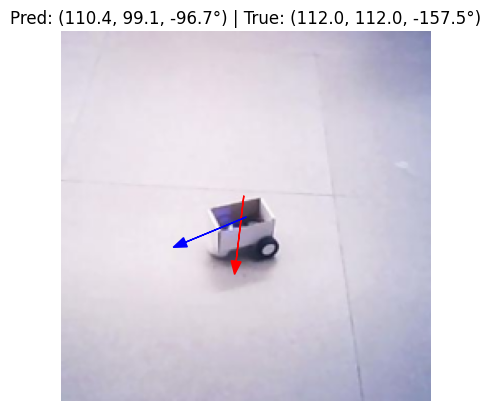


Image 4:
  Ground Truth (x, y, angle): [112.          81.51111126 173.74596834]
  Predicted     (x, y, angle): [104.82289982  71.71412468 177.4666965 ]
Predicted X norm: 0.46795937418937683, denorm: 104.8228988647461
True X norm: 0.5, denorm: 112.0


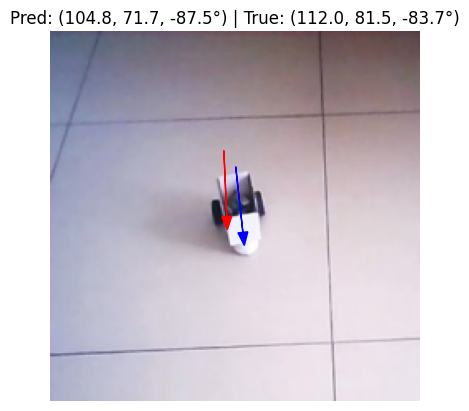


Image 5:
  Ground Truth (x, y, angle): [112.          64.71111393 281.84208155]
  Predicted     (x, y, angle): [112.39689827  67.02321625 214.48709249]
Predicted X norm: 0.501771867275238, denorm: 112.39689636230469
True X norm: 0.5, denorm: 112.0


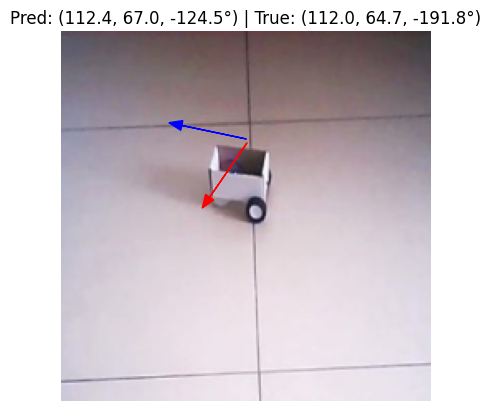

In [ ]:
visualize_predictions(net, test_loader, device, num_images=5)

# **Step 9.7:** Show Accuracy for (X,Y) and Angle Predictions on Test Set

In [ ]:
def evaluate_pose_accuracy(net, test_loader, device):
    net.eval()

    total_samples = 0
    total_x_error = 0.0
    total_y_error = 0.0
    total_angle_error = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)

            # Unnormalize both predictions and labels
            preds = outputs.cpu().numpy() * np.array([max_x, max_y, max_angle])
            trues = labels.cpu().numpy() * np.array([max_x, max_y, max_angle])

            # Compute absolute errors
            total_x_error += np.abs(preds[:, 0] - trues[:, 0]).sum()
            total_y_error += np.abs(preds[:, 1] - trues[:, 1]).sum()
            total_angle_error += np.abs(preds[:, 2] - trues[:, 2]).sum()
            total_samples += preds.shape[0]

    # Compute mean errors (MAE)
    mean_x_error = total_x_error / total_samples
    mean_y_error = total_y_error / total_samples
    mean_angle_error = total_angle_error / total_samples

    print("For new Loss function:")
    print("Prediction Accuracy on Test Set:")
    print(f"  Mean Absolute Error in X:     {mean_x_error:.2f} pixels")
    print(f"  Mean Absolute Error in Y:     {mean_y_error:.2f} pixels")
    print(f"  Mean Absolute Error in Angle: {mean_angle_error:.2f} degrees")


In [ ]:
evaluate_pose_accuracy(net, test_loader, device)

For new Loss function:
Prediction Accuracy on Test Set:
  Mean Absolute Error in X:     11.70 pixels
  Mean Absolute Error in Y:     20.02 pixels
  Mean Absolute Error in Angle: 72.71 degrees
